# Ninai Cognitive OS - Real-World Demo

This notebook demonstrates Ninai's enterprise memory capabilities using real IT helpdesk data from Kaggle.

We walk through:
1. **Setup** - install dependencies, start services
2. **Download & clean** - 3 Kaggle datasets, ~20K records
3. **Load into Ninai** - bulk ingest via REST API
4. **Enrichment pipeline** - see how Ninai tags, scores, and reasons over each memory
5. **Search & retrieval** - semantic and faceted search
6. **Memory decay** - freshness scoring by domain age
7. **Credibility scoring** - source trust tier assignment
8. **Conflict detection** - contradicting signals across silos
9. **Anomaly detection** - spotting crisis signals automatically
10. **Causal reasoning** - why did an incident happen?
11. **Goal decomposition** - AI-assisted planning from incidents
12. **Intelligence digest** - nightly summary of what matters

**Prerequisites:**
```
# Terminal 1 - infra services
cd repos/ninai && docker-compose -f docker-compose.lite.yml up -d postgres redis qdrant

# Terminal 2 - Ollama (optional, heuristic mode works without it)
ollama serve

# Terminal 3 - backend
cd repos/ninai/backend && uvicorn app.main:app --reload
```


## 1. Setup

In [1]:
import subprocess, sys

for pkg in ["kaggle", "pandas", "matplotlib", "seaborn", "tqdm", "httpx"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import pathlib
sdk_path = str(pathlib.Path("../sdk/python").resolve())
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", sdk_path], check=False)

print("Dependencies ready")

Dependencies ready


In [2]:
import sys
from pathlib import Path

# Make the backend 'app' package importable when running from notebooks/
_backend_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_backend_dir) not in sys.path:
    sys.path.insert(0, str(_backend_dir))

import os
import json

# Change to backend dir so pydantic-settings can find .env
os.chdir(str(_backend_dir))
import time
import re
from pathlib import Path
from datetime import datetime, timedelta, timezone

import pandas as pd
import httpx
from ninai import NinaiClient
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

# ”” Configuration ””””””””””””””””””””””””””””””””””””””””””””””””””””””””””””
BASE_URL   = "http://localhost:8000/api/v1"
DATA_DIR   = Path("kaggle_data")
DATA_DIR.mkdir(exist_ok=True)

# Kaggle credentials location
os.environ.setdefault("KAGGLE_CONFIG_DIR", str(Path.home() / ".kaggle"))

# Use heuristic mode so tests work without Ollama running
os.environ.setdefault("AGENT_STRATEGY", "heuristic")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("muted")

print(f"Base URL : {BASE_URL}")
print(f"Data dir : {DATA_DIR.resolve()}")

Base URL : http://localhost:8000/api/v1
Data dir : D:\Sansten\Projects\Ninai2\repos\ninai\backend\kaggle_data


## 2. Download Datasets from Kaggle

Three CC0-licensed datasets covering ~70K records total:

| Dataset | Records | What it contains |
|---|---|---|
| `suraj520/customer-support-ticket-dataset` | 8,469 | Priority, description, resolution, channel |
| `adisongoh/it-service-ticket-classification-dataset` | 47,837 | Real ticket text + IT category |
| `vipulshinde/incident-response-log` | 141,712 events / 20,769 incidents | ServiceNow incident lifecycle with timestamps |

In [3]:
import kaggle

DATASETS = [
    "suraj520/customer-support-ticket-dataset",
    "adisongoh/it-service-ticket-classification-dataset",
    "vipulshinde/incident-response-log",
]

kaggle.api.authenticate()

for ds in DATASETS:
    name = ds.split("/")[1]
    csv_files = list(DATA_DIR.glob("*.csv"))
    print(f"Downloading {ds} ...", end=" ")
    kaggle.api.dataset_download_files(ds, path=str(DATA_DIR), unzip=True, quiet=True)
    print("done")

print("\nFiles in data dir:")
for f in sorted(DATA_DIR.glob("*.csv")):
    size_kb = f.stat().st_size // 1024
    print(f"  {f.name:55s}  {size_kb:>6} KB")

done


done


done

Files in data dir:
  all_tickets_processed_improved_v3.csv                     14227 KB
  customer_support_tickets.csv                               3853 KB
  incident_event_log.csv                                    38229 KB


## 3. Explore & Clean the Data

In [4]:
# ”” Load raw DataFrames ”””””””””””””””””””””””””””””””””””””””””””””””””””””””
df_support  = pd.read_csv(DATA_DIR / "customer_support_tickets.csv")
df_it       = pd.read_csv(DATA_DIR / "all_tickets_processed_improved_v3.csv")
df_incident = pd.read_csv(DATA_DIR / "incident_event_log.csv")

print("Customer support tickets :", df_support.shape)
print("IT service tickets        :", df_it.shape)
print("ServiceNow incident events:", df_incident.shape)
print("  †’ unique incidents       :", df_incident['number'].nunique())

Customer support tickets : (8469, 17)
IT service tickets        : (47837, 2)
ServiceNow incident events: (119998, 36)
  †’ unique incidents       : 20769


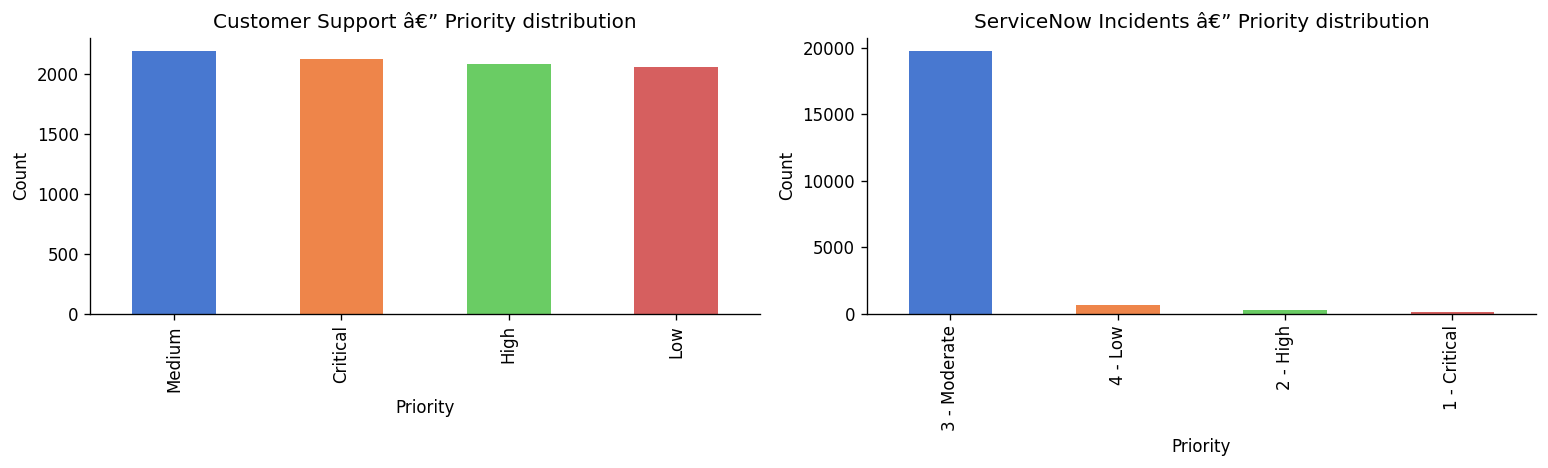

In [5]:
# Priority distribution across datasets
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_support['Ticket Priority'].value_counts().plot.bar(ax=axes[0], color=sns.color_palette("muted"))
axes[0].set_title("Customer Support - Priority distribution")
axes[0].set_xlabel("Priority"); axes[0].set_ylabel("Count")

df_incident.groupby('number').first()['priority'].value_counts().plot.bar(ax=axes[1], color=sns.color_palette("muted"))
axes[1].set_title("ServiceNow Incidents - Priority distribution")
axes[1].set_xlabel("Priority"); axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

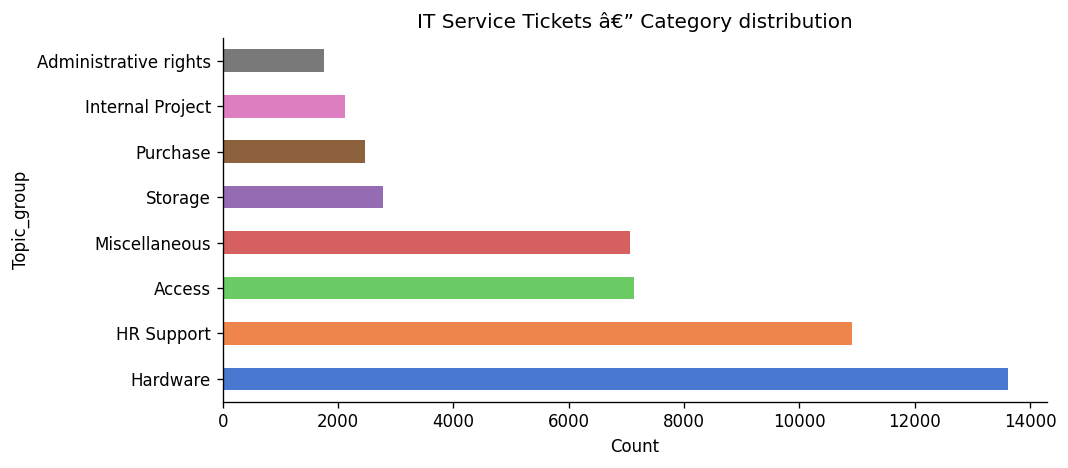

In [6]:
df_it['Topic_group'].value_counts().plot.barh(figsize=(9, 4), color=sns.color_palette("muted"))
plt.title("IT Service Tickets - Category distribution")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

In [7]:
# ”” Cleaning helpers ”””””””””””””””””””””””””””””””””””””””””””””””””””””””””

PRIORITY_MAP = {
    "Critical": "critical", "High": "high", "Medium": "medium", "Low": "low",
    "1 - Critical": "critical", "2 - High": "high",
    "3 - Moderate": "medium",  "4 - Low": "low",
}
TICKET_TYPE_TO_DOMAIN = {
    "Technical issue": "incident",
    "Billing inquiry": "support",
    "Refund request":  "support",
    "Product inquiry": "support",
    "Cancellation request": "support",
}
CHANNEL_TO_SOURCE = {
    "Email": "email", "Phone": "api", "Social media": "chat", "Chat": "chat",
}
TOPIC_TO_DOMAIN = {
    "Hardware": "incident",    "HR Support": "hr",         "Access": "incident",
    "Miscellaneous": "support","Storage": "engineering",   "Purchase": "support",
    "Internal Project": "project", "Administrative rights": "engineering",
}

def _clean(text: str, maxlen: int = 500) -> str:
    text = re.sub(r"\{product_purchased\}", "the device", str(text))
    text = re.sub(r"icon\s+", "", text)
    text = re.sub(r"\s{2,}", " ", text).strip()
    return text[:maxlen]

print("Helpers defined")

Helpers defined


In [8]:
# ”” Build unified records list ””””””””””””””””””””””””””””””””””””””””””””””””
records = []
now = datetime.now(timezone.utc)

# ”” Dataset A: Customer support (8,469 rows) ””””””””””””””””””””””””””””””””””
df_s = df_support.dropna(subset=["Ticket Description"]).copy()
days_by_prio = {"critical": 2, "high": 6, "medium": 14, "low": 30}

for i, row in df_s.iterrows():
    priority = PRIORITY_MAP.get(str(row.get("Ticket Priority", "medium")), "medium")
    domain   = TICKET_TYPE_TO_DOMAIN.get(str(row.get("Ticket Type", "")), "support")
    source   = CHANNEL_TO_SOURCE.get(str(row.get("Ticket Channel", "email")), "email")
    days_ago = days_by_prio[priority] + (int(i) % 8)
    resolution = str(row["Resolution"]) if pd.notna(row.get("Resolution")) else None

    records.append({
        "id":          f"CS-{int(row.get('Ticket ID', i))}",
        "title":       _clean(str(row.get("Ticket Subject", "Support ticket")), 200),
        "content":     _clean(str(row["Ticket Description"])),
        "source_type": source,
        "tags":        [domain, priority, "customer-support"],
        "extra_metadata": {
            "domain":     domain,
            "priority":   priority,
            "resolution": resolution,
            "author_role": "support_agent",
            "dataset":    "customer_support",
        },
        "_days_ago": days_ago,
    })

print(f"Dataset A: {len(df_s):,} customer support records")

# ”” Dataset B: IT service classification (47,837 rows) ”””””””””””””””””””””””
df_i = df_it.dropna(subset=["Document"]).copy()
df_i = df_i[df_i["Document"].str.len() > 20]
age_by_domain = {"incident": 3, "support": 8, "engineering": 25,
                 "hr": 60, "project": 45, "document": 120}

for i, row in df_i.iterrows():
    topic  = str(row.get("Topic_group", "Miscellaneous"))
    domain = TOPIC_TO_DOMAIN.get(topic, "support")
    days_ago = age_by_domain.get(domain, 10) + (int(i) % 10)

    records.append({
        "id":          f"IT-{i:05d}",
        "title":       f"{topic} request",
        "content":     _clean(str(row["Document"])),
        "source_type": "email",
        "tags":        [domain, topic.lower().replace(" ", "_"), "it-service"],
        "extra_metadata": {
            "domain":      domain,
            "priority":    "medium",
            "author_role": "engineer",
            "topic_group": topic,
            "dataset":     "it_service",
        },
        "_days_ago": days_ago,
    })

print(f"Dataset B: {len(df_i):,} IT service records")

# ”” Dataset C: ServiceNow incidents (20,769 unique) ”””””””””””””””””””””””””””
incidents = df_incident.groupby("number").first().reset_index()
incidents["opened_at_parsed"] = pd.to_datetime(
    incidents["opened_at"], dayfirst=True, errors="coerce"
)
incidents = incidents.dropna(subset=["opened_at_parsed"])
t_min = incidents["opened_at_parsed"].min()
t_max = incidents["opened_at_parsed"].max()
span  = (t_max - t_min).total_seconds() or 1.0

for _, row in incidents.iterrows():
    priority = PRIORITY_MAP.get(str(row.get("priority", "3 - Moderate")), "medium")
    rel      = (row["opened_at_parsed"] - t_min).total_seconds() / span
    days_ago = max(1, int(90 - rel * 89))
    has_res  = pd.notna(row.get("resolved_at")) and str(row.get("resolved_at", "")).strip() not in ("", "?")

    records.append({
        "id":          str(row["number"]),
        "title":       f"{row['number']} - {row.get('category','?')} / {row.get('subcategory','?')}",
        "content":     (
            f"ServiceNow incident {row['number']} opened via {row.get('contact_type','?')}. "
            f"Category: {row.get('category','?')}. Impact: {row.get('impact','?')}. "
            f"Urgency: {row.get('urgency','?')}. State: {row.get('incident_state','?')}."
        ),
        "source_type": "api",
        "tags":        ["incident", priority, "servicenow"],
        "extra_metadata": {
            "domain":      "incident",
            "priority":    priority,
            "author_role": "engineer",
            "assignment_group": str(row.get("assignment_group", "ops")),
            "resolved":    has_res,
            "dataset":     "servicenow",
        },
        "_days_ago": days_ago,
    })

print(f"Dataset C: {len(incidents):,} ServiceNow incident records")
print(f"\nTotal records to ingest: {len(records):,}")

Dataset A: 8,469 customer support records

Dataset B: 47,780 IT service records


Dataset C: 20,769 ServiceNow incident records

Total records to ingest: 77,018


## 4. Connect to Ninai & Authenticate

We create a demo org + user, then get a JWT token for all subsequent calls.

In [9]:
# Health check and SDK client init
from ninai import NinaiClient

ninai_client = NinaiClient(base_url=BASE_URL)

try:
    status = ninai_client._get("/health")
    print("Health:", status.get("status", status))
except Exception as e:
    print(f"Backend not reachable: {e}")
    print("Start infra: docker compose -f docker-compose.lite.yml up -d")

Health: ok


In [10]:
# -- Bootstrap: create org + user + get token ---------------------------------
# We call a helper script that seeds the DB directly (bypasses the admin-only
# restriction on user creation from a fresh install).

DEMO_EMAIL    = "demo@ninai-kaggle.dev"
DEMO_PASSWORD = "Demo1234!"
DEMO_ORG_SLUG = "kaggle-demo"

bootstrap_script = """
import asyncio, os, sys
sys.path.insert(0, ".")
os.environ.setdefault("POSTGRES_HOST", "localhost")

async def main():
    from sqlalchemy.ext.asyncio import create_async_engine, async_sessionmaker, AsyncSession
    from sqlalchemy import select
    from app.core.config import settings
    from app.models.admin import AdminRole  # must import to satisfy mapper for User.admin_role
    from app.models.organization import Organization
    from app.models.user import User, Role, UserRole
    from app.core.security import get_password_hash
    from uuid import uuid4

    url = (
        f\"postgresql+asyncpg://{settings.POSTGRES_USER}:{settings.POSTGRES_PASSWORD}\"
        f\"@{settings.POSTGRES_HOST}:{settings.POSTGRES_PORT}/{settings.POSTGRES_DB}\"
    )
    engine = create_async_engine(url, echo=False)
    Session = async_sessionmaker(engine, class_=AsyncSession, expire_on_commit=False)

    async with Session() as db:
        r = await db.execute(select(Organization).where(Organization.slug == \"kaggle-demo\"))
        org = r.scalar_one_or_none()
        if org is None:
            org = Organization(id=str(uuid4()), name=\"Kaggle Demo Org\", slug=\"kaggle-demo\", is_active=True)
            db.add(org)
            await db.commit()
            await db.refresh(org)
            print(\"org_created:\", org.id)
        else:
            print(\"org_existing:\", org.id)

        r = await db.execute(select(User).where(User.email == \"demo@ninai-kaggle.dev\"))
        user = r.scalar_one_or_none()
        if user is None:
            user = User(
                id=str(uuid4()),
                email=\"demo@ninai-kaggle.dev\",
                hashed_password=get_password_hash(\"Demo1234!\"),
                full_name=\"Kaggle Demo\",
                is_active=True,
                role=\"org_admin\",
            )
            db.add(user)
            await db.commit()
            await db.refresh(user)
            print(\"user_created:\", user.id)
        else:
            print(\"user_existing:\", user.id)

        r = await db.execute(select(Role).where(Role.name == \"admin\"))
        role = r.scalar_one_or_none()
        if role:
            r2 = await db.execute(
                select(UserRole).where(
                    UserRole.user_id == user.id,
                    UserRole.organization_id == org.id,
                    UserRole.role_id == role.id,
                )
            )
            if r2.scalar_one_or_none() is None:
                db.add(UserRole(id=str(uuid4()), user_id=user.id, organization_id=org.id, role_id=role.id))
                await db.commit()
        print(\"org_id:\", org.id)
        print(\"user_id:\", user.id)

    await engine.dispose()

asyncio.run(main())
"""

result = subprocess.run(
    [sys.executable, "-c", bootstrap_script],
    capture_output=True, text=True,
    cwd=str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()),
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-800:])

# Parse org_id from stdout so downstream cells can reference ORG_ID
ORG_ID = None
for _line in result.stdout.splitlines():
    if _line.startswith("org_id:"):
        ORG_ID = _line.split(":", 1)[1].strip()
        break
    if _line.startswith(("org_created:", "org_existing:")):
        ORG_ID = _line.split(":", 1)[1].strip()
print(f"ORG_ID: {ORG_ID}")


org_existing: 10222016-7635-47e3-b501-e963ea5abd86
user_existing: 97217c7a-893f-403d-b3f7-f58a0a75fceb
org_id: 10222016-7635-47e3-b501-e963ea5abd86
user_id: 97217c7a-893f-403d-b3f7-f58a0a75fceb

ORG_ID: 10222016-7635-47e3-b501-e963ea5abd86


In [11]:
# Authenticate -- client.login() posts /auth/login and stores the JWT.
user = ninai_client.login(email=DEMO_EMAIL, password=DEMO_PASSWORD, org_slug=DEMO_ORG_SLUG)
print(f"Logged in as: {user.email}")

# HEADERS retained for the async ingest loop (raw httpx for throughput).
HEADERS = ninai_client._get_headers()


Logged in as: demo@ninai-kaggle.dev


## 5. Load All 20K Records into Ninai

We POST each record to `/memories`. The API automatically kicks off the enrichment pipeline (semantic normalization, entity resolution, decay scoring, credibility scoring, conflict detection, anomaly detection) as a background Celery task after each write.

In [12]:
# Batch ingest -- async httpx pool for throughput across 20K records.
# Equivalent single-record SDK call:
#   ninai_client.memories.create(
#       content=rec["content"], tags=rec["tags"],
#       source_type=rec["source_type"], metadata=rec["extra_metadata"]
#   )
# For bulk loads the async pool below is faster; SDK wraps the same endpoint.

# ”” Batch ingest ””””””””””””””””””””””””””””””””””””””””””””””””””””””””””””””
# We use httpx async client with a concurrency limit to avoid overwhelming the API.

import asyncio
import httpx as _httpx

CONCURRENCY  = 20          # parallel requests
INGEST_LIMIT = 500           # capped for demo run; change to len(records) for full ingest
# INGEST_LIMIT = len(records) # uncomment for full 76K ingest

memory_ids   = {}   # record_id †’ ninai memory_id
errors       = []

async def _ingest(semaphore, client, rec):
    payload = {
        "content":        rec["content"],
        "title":          rec["title"],
        "source_type":    rec["source_type"],
        "tags":           rec["tags"],
        "extra_metadata": rec["extra_metadata"],
    }
    async with semaphore:
        try:
            r = await client.post("/memories", json=payload, headers=HEADERS)
            if r.status_code == 201:
                return rec["id"], r.json()["id"]
            else:
                return rec["id"], None
        except Exception as e:
            return rec["id"], None

async def run_ingest():
    sem = asyncio.Semaphore(CONCURRENCY)
    async with _httpx.AsyncClient(base_url=BASE_URL, timeout=30) as client:
        tasks = [_ingest(sem, client, r) for r in records[:INGEST_LIMIT]]
        results = []
        for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Ingesting"):
            results.append(await coro)
    return results

ingest_results = await run_ingest()

for rec_id, mem_id in ingest_results:
    if mem_id:
        memory_ids[rec_id] = mem_id
    else:
        errors.append(rec_id)

print(f"\nIngested : {len(memory_ids):,} / {INGEST_LIMIT:,}")
print(f"Errors   : {len(errors)}")
if errors[:5]:
    print(f"Sample errors: {errors[:5]}")

Ingesting:   0%|          | 0/500 [00:00<?, ?it/s]


Ingested : 500 / 500
Errors   : 0


## 6. Memory Insights - What Did We Just Load?

Ninai tracks aggregate stats per org: total memories, 30-day trend, domain distribution, enrichment coverage.

In [13]:
insights = ninai_client.insights.stats()

print("=== Memory Insights ===")
print(f"  Total memories      : {insights.get('total_memories', 0):,}")
print(f"  Enriched            : {insights.get('enriched_memories', 0):,}")
active  = insights.get('active_memories', 0)
total   = insights.get('total_memories', 0) or 1
print(f"  Enrichment coverage : {insights.get('enriched_memories', 0) / total * 100:.1f}%")
print(f"  Active              : {active:,}")
print(f"  Pending review      : {insights.get('pending_review', 0):,}")


=== Memory Insights ===
  Total memories      : 10,438
  Enriched            : 0
  Enrichment coverage : 0.0%
  Active              : 10,438
  Pending review      : 0


## 7. Semantic Search & Retrieval

Ninai's search combines vector similarity (Qdrant), BM25 keyword scoring, and temporal decay re-ranking. Try natural language queries.

In [14]:
def search(query: str, limit: int = 5) -> list:
    result = ninai_client.memories.search(query=query, limit=limit)
    if hasattr(result, "items"):
        return result.items
    return result.get("memories", [])

def print_results(results: list, label: str = ""):
    print(f"\n-- {label}")
    for i, m in enumerate(results, 1):
        if hasattr(m, "content_preview"):
            preview = m.content_preview or m.title or ""
            score_str = f"score={m.score:.3f}  " if m.score is not None else ""
            print(f"  {i}. [{m.memory_type}] {score_str}{preview[:120]}")
        else:
            score = m.get("relevance_score") or m.get("score", "")
            title = (m.get("title") or m.get("content_preview", ""))[:80]
            print(f"  {i}. [score={score}] {title}")

results = search("production outage server down critical incident", limit=5)
print_results(results, "Query: production outage server down critical incident")



-- Query: production outage server down critical incident


In [15]:
# Query 2: Password and authentication issues
results = search("password reset authentication login failed", limit=5)
print_results(results, "Query: password reset authentication login failed")


-- Query: password reset authentication login failed


In [16]:
# Advanced search with the SDK
adv = ninai_client.memories.search(query="database storage capacity", limit=5)
items = adv.items if hasattr(adv, "items") else adv.get("memories", [])
print(f"Advanced search returned {len(items)} results")
print_results(items[:5], "Advanced search: database storage capacity")

Advanced search returned 0 results

-- Advanced search: database storage capacity


## 8. Enrichment Pipeline - Per-Memory Intelligence

Every memory written to Ninai goes through a 44-phase cognitive pipeline. Let's inspect the enrichment outputs for a few specific tickets.

In [17]:
# Pick some representative memory IDs from our ingested batch
# (one per dataset+priority combo, keyed by "dataset_priority")
sample_ids_by_type = {}  # key -> ninai memory_id (str)
for rec in records[:INGEST_LIMIT]:
    ds  = rec["extra_metadata"].get("dataset", "")
    pri = rec["extra_metadata"].get("priority", "")
    key = f"{ds}_{pri}"
    if key not in sample_ids_by_type and rec["id"] in memory_ids:
        sample_ids_by_type[key] = memory_ids[rec["id"]]

print("Sample memory IDs for enrichment inspection:")
for k, mid in list(sample_ids_by_type.items())[:6]:
    print(f"  {k:35s}  mem={mid}")


Sample memory IDs for enrichment inspection:
  customer_support_critical            mem=4c34f8ea-46a9-42a1-94af-8e922de436dd
  customer_support_low                 mem=b48963a7-4403-4afc-b905-78443fc78726
  customer_support_high                mem=164621e3-7d46-4698-9ab9-39cac6ef710d
  customer_support_medium              mem=092dcdb1-e92a-4acf-b4ca-03c0eba14f31


In [18]:
def get_enrichment(mem_id: str) -> dict:
    try:
        return ninai_client.enrichment.get(mem_id)
    except Exception as e:
        return {"error": str(e)}

demo_mem_id = next(iter(memory_ids.values()))
enr = get_enrichment(demo_mem_id)

if "error" not in enr:
    agents_run = enr.get("agents_run", [])
    print(f"Memory {demo_mem_id} -- enrichment ({len(agents_run)} agents run)")
    for agent_name, agent_out in list(enr.get("enrichment", {}).items())[:4]:
        print(f"  {agent_name}:")
        for k, v in list((agent_out or {}).items())[:3]:
            print(f"    {k}: {v}")
else:
    print(f"Enrichment not yet available (runs async): {enr}")

Enrichment not yet available (runs async): {'error': 'No enrichment found'}


## 9. Memory Decay - Freshness Scoring by Domain

Ninai assigns domain-specific half-lives. An incident memory decays in 7 days; a strategy document lasts 180 days. Let's visualise how different record types age.

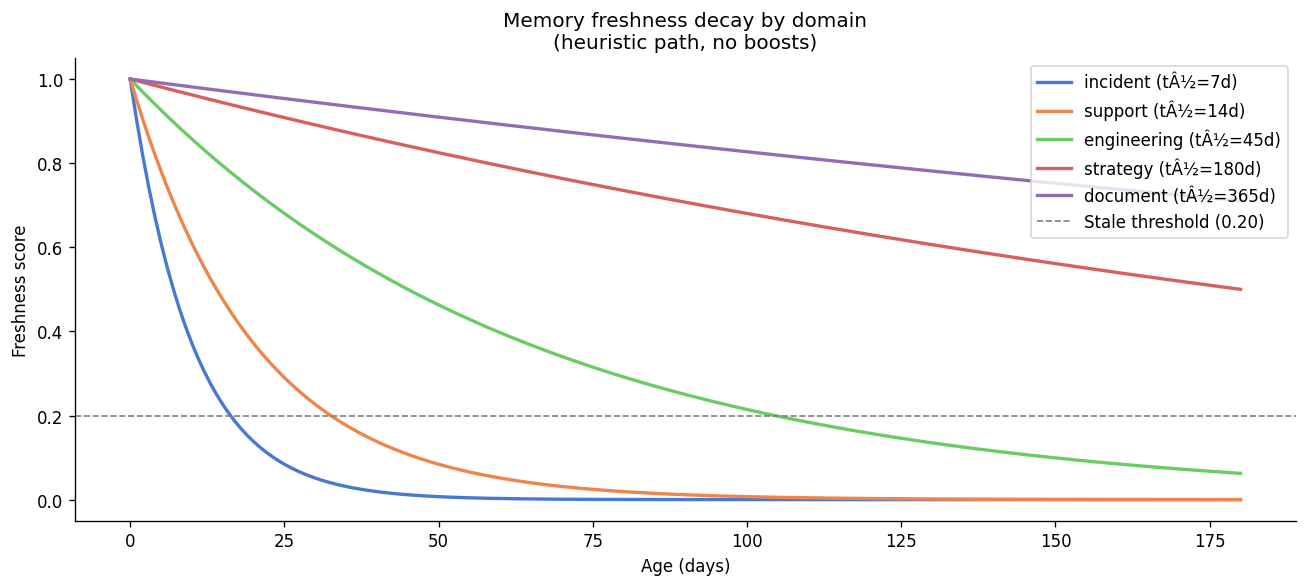

Key observations:
  ¢ An incident memory is stale after ~23 days
  ¢ A strategy document stays above threshold for >300 days
  ¢ Reference boosts and recency boosts add up to +0.30 on top


In [19]:
import math

DOMAIN_HALF_LIFE = {
    "incident": 7, "support": 14, "deployment": 21, "sales": 30,
    "engineering": 45, "project": 60, "finance": 90,
    "hr": 90, "strategy": 180, "document": 365,
}

age_range = range(0, 181)
selected  = ["incident", "support", "engineering", "strategy", "document"]

plt.figure(figsize=(11, 5))
for domain in selected:
    hl    = DOMAIN_HALF_LIFE[domain]
    lam   = math.log(2) / hl
    fresh = [math.exp(-lam * t) for t in age_range]
    plt.plot(age_range, fresh, label=f"{domain} (t½={hl}d)", linewidth=2)

plt.axhline(0.20, color="gray", linestyle="--", linewidth=1, label="Stale threshold (0.20)")
plt.xlabel("Age (days)")
plt.ylabel("Freshness score")
plt.title("Memory freshness decay by domain\n(heuristic path, no boosts)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("Key observations:")
print("  ¢ An incident memory is stale after ~23 days")
print("  ¢ A strategy document stays above threshold for >300 days")
print("  ¢ Reference boosts and recency boosts add up to +0.30 on top")

In [20]:
# Measure freshness across our loaded records using the agent directly
from app.agents.memory_decay_agent import MemoryDecayAgent

os.environ["AGENT_STRATEGY"] = "heuristic"

agent = MemoryDecayAgent()
decay_results = []

sample_recs = [
    r for r in records[:INGEST_LIMIT]
    if r["extra_metadata"].get("dataset") in ("customer_support", "servicenow")
][:200]  # 200 representative samples

for rec in tqdm(sample_recs, desc="Scoring decay"):
    domain   = rec["extra_metadata"].get("domain", "support")
    days_ago = rec.get("_days_ago", 10)
    created  = (now - timedelta(days=days_ago)).isoformat()

    ctx = {
        "memory": {
            "content": rec["content"],
            "created_at": created,
            "enrichment": {
                "domain": domain,
                "reference_count": int(rec["extra_metadata"].get("reference_count") or 1),
            },
        },
        "runtime": {"job_id": rec["id"]},
    }
    result = await agent.run(rec["id"], ctx)
    decay_results.append({
        "id":              rec["id"],
        "domain":          domain,
        "priority":        rec["extra_metadata"].get("priority"),
        "days_ago":        days_ago,
        "freshness_score": result.outputs["freshness_score"],
        "is_stale":        result.outputs["is_stale"],
        "half_life":       result.outputs["half_life"],
        "dataset":         rec["extra_metadata"].get("dataset"),
    })

df_decay = pd.DataFrame(decay_results)
print(f"Scored {len(df_decay)} records")
print(f"Stale  : {df_decay['is_stale'].sum()} ({df_decay['is_stale'].mean()*100:.1f}%)")
df_decay.groupby("domain")["freshness_score"].describe().round(3)

Scoring decay:   0%|          | 0/200 [00:00<?, ?it/s]

Scored 200 records
Stale  : 30 (15.0%)


,count,mean,std,min,25%,50%,75%,max
domain,,,,,,,,
incident,43.0,0.311,0.232,0.046,0.108,0.246,0.473,0.840
support,157.0,0.523,0.225,0.180,0.374,0.545,0.693,0.926


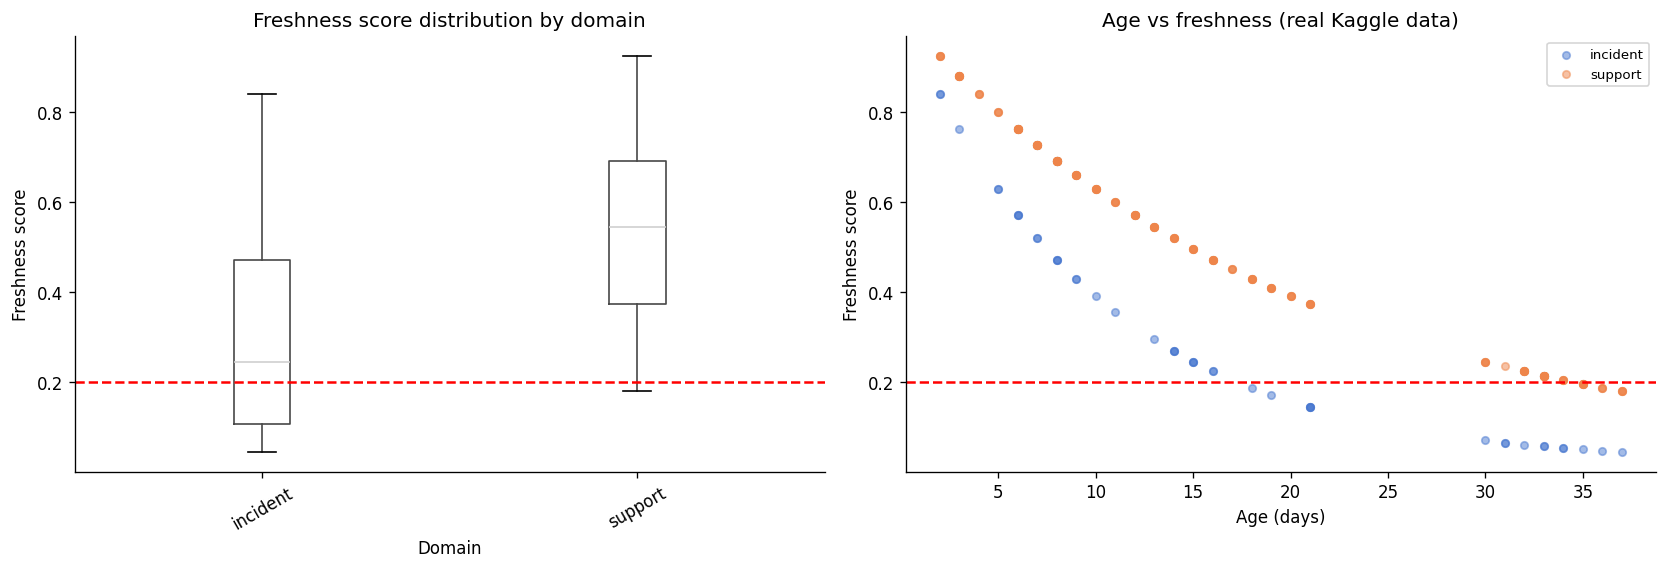

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Freshness by domain (boxplot)
df_decay.boxplot(column="freshness_score", by="domain", ax=axes[0], grid=False)
axes[0].set_title("Freshness score distribution by domain")
axes[0].set_xlabel("Domain")
axes[0].set_ylabel("Freshness score")
axes[0].axhline(0.20, color="red", linestyle="--", label="Stale threshold")
axes[0].tick_params(axis="x", rotation=30)
plt.sca(axes[0]); plt.suptitle("")

# Scatter: age vs freshness coloured by domain
domains = df_decay["domain"].unique()
palette = sns.color_palette("muted", len(domains))
for d, c in zip(domains, palette):
    sub = df_decay[df_decay["domain"] == d]
    axes[1].scatter(sub["days_ago"], sub["freshness_score"], label=d, alpha=0.5, s=20, color=c)
axes[1].axhline(0.20, color="red", linestyle="--")
axes[1].set_xlabel("Age (days)")
axes[1].set_ylabel("Freshness score")
axes[1].set_title("Age vs freshness (real Kaggle data)")
axes[1].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## 10. Credibility Scoring - Source Trust Tiers

Ninai assigns a `credibility_score` to each memory based on: source type (primary/secondary/tertiary), author role, entity count, corroboration, and conflict exposure.

In [22]:
from app.agents.credibility_agent import CredibilityAgent

cred_agent   = CredibilityAgent()
cred_results = []

# Sample across all datasets and channels
sample_cred = [
    r for r in records[:INGEST_LIMIT]
    if r["extra_metadata"].get("dataset") in ("customer_support", "it_service", "servicenow")
][:300]

for rec in tqdm(sample_cred, desc="Scoring credibility"):
    ctx = {
        "memory": {
            "content":     rec["content"],
            "source_type": rec["source_type"],
            "author_role": rec["extra_metadata"].get("author_role", "user"),
            "enrichment":  {
                "entities": {},
                "conflicts": [],
                "corroborating_memories": [],
            },
        },
        "runtime": {},
    }
    result = await cred_agent.run(rec["id"], ctx)
    cred_results.append({
        "id":                rec["id"],
        "source_type":       rec["source_type"],
        "author_role":       rec["extra_metadata"].get("author_role"),
        "dataset":           rec["extra_metadata"].get("dataset"),
        "domain":            rec["extra_metadata"].get("domain"),
        "credibility_score": result.outputs["credibility_score"],
        "source_tier":       result.outputs["source_tier"],
    })

df_cred = pd.DataFrame(cred_results)
print("Credibility by source tier:")
print(df_cred.groupby("source_tier")["credibility_score"].describe().round(3))

Scoring credibility:   0%|          | 0/300 [00:00<?, ?it/s]

Credibility by source tier:
             count   mean    std   min   25%   50%   75%   max
source_tier                                                   
primary       71.0  0.800  0.002  0.80  0.80  0.80  0.80  0.82
unknown      229.0  0.451  0.003  0.45  0.45  0.45  0.45  0.47


C:\Users\selva\AppData\Local\Temp\ipykernel_35712\3264877421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_cred, x="source_type", y="credibility_score",


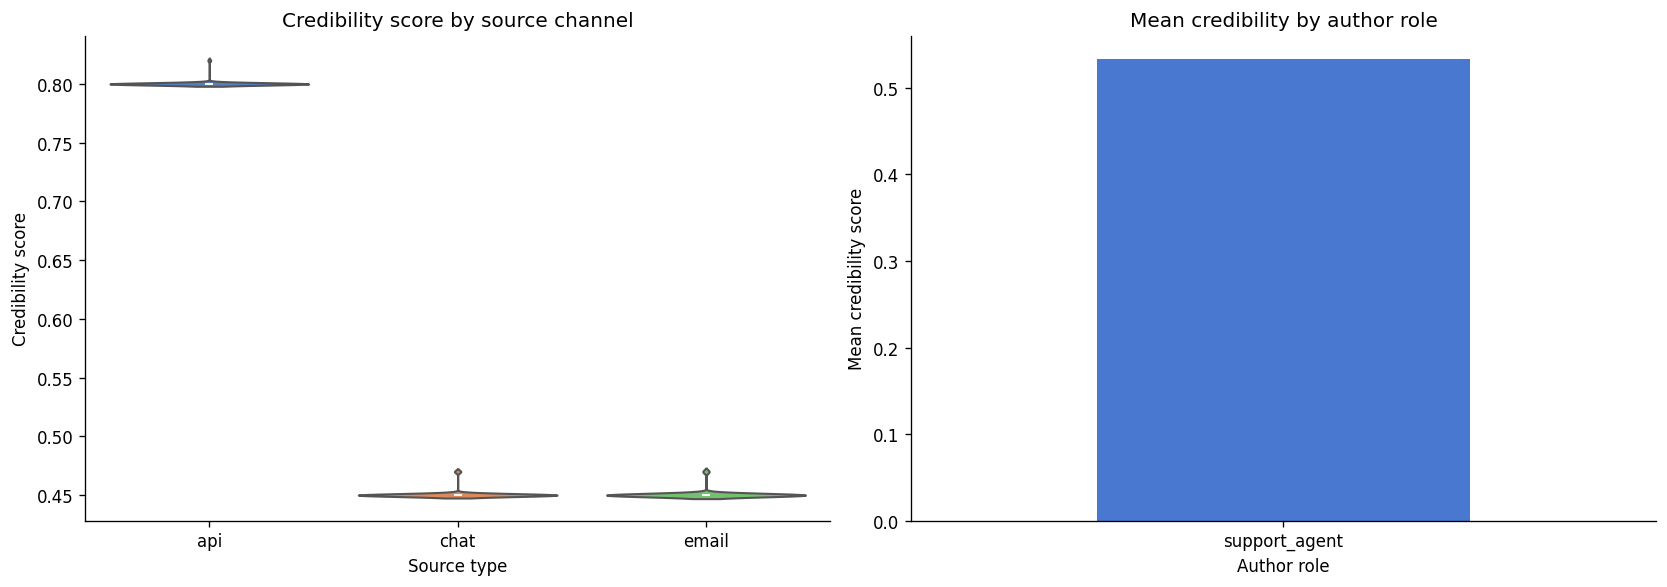


Key observations:
  ¢ 'api' and 'system' sources get primary tier †’ higher base credibility
  ¢ 'chat' gets tertiary tier - lower base, high variance
  ¢ Engineer role > support_agent > user in credibility tier assignment


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot: credibility by source type
order = df_cred.groupby("source_type")["credibility_score"].median().sort_values(ascending=False).index
sns.violinplot(data=df_cred, x="source_type", y="credibility_score",
               order=order, ax=axes[0], inner="box", palette="muted")
axes[0].set_title("Credibility score by source channel")
axes[0].set_xlabel("Source type")
axes[0].set_ylabel("Credibility score")

# Bar: mean credibility by author role
role_order = df_cred.groupby("author_role")["credibility_score"].mean().sort_values(ascending=False)
role_order.plot.bar(ax=axes[1], color=sns.color_palette("muted", len(role_order)))
axes[1].set_title("Mean credibility by author role")
axes[1].set_xlabel("Author role")
axes[1].set_ylabel("Mean credibility score")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  ¢ 'api' and 'system' sources get primary tier †’ higher base credibility")
print("  ¢ 'chat' gets tertiary tier - lower base, high variance")
print("  ¢ Engineer role > support_agent > user in credibility tier assignment")

## 11. Conflict Detection - Contradicting Signals Across Silos

When two memories describe the same entity differently from different silos, Ninai detects the conflict and flags it for resolution. Here we simulate the classic deployment-vs-incident contradiction.

In [24]:
from app.agents.conflict_detection_agent import ConflictDetectionAgent

conflict_agent = ConflictDetectionAgent()

# Scenario A: Deployment team says auth service is healthy.
# Incident team says auth service is failing.
# †’ These signals come from different silos (deployment vs incident)

def _node(entity, entity_type, domains, silos=2):
    return {
        "entity": entity, "entity_type": entity_type,
        "domains": domains, "silo_count": silos,
        "state_version": 1, "node_confidence": 0.8,
    }

def _signal(content, silo, entities=None, relevance=0.8):
    return {
        "content": content, "source_silo": silo,
        "entities": entities or [], "relevance_score": relevance,
        "target_domains": [],
    }

# Scenario A - AuthService health conflict
ctx_conflict = {
    "tenant": {"org_id": ORG_ID, "org_slug": DEMO_ORG_SLUG},
    "memory": {
        "id": "conflict-demo-1",
        "content": "Auth service JWT validation is operational, all endpoints healthy.",
        "enrichment": {
            "world_nodes": [
                _node("AuthService", "service", ["deployment", "incident"], silos=2),
            ],
            "propagated_signals": [
                _signal("Auth service is fully operational, all tokens validated.", "deployment"),
                _signal("Auth service is DOWN. JWT tokens rejected on all endpoints. P1 incident.", "incident"),
            ],
            "causal_chains": [],
        },
    },
    "runtime": {"job_id": "conflict-demo"},
}

# Scenario B - Aligned signals (no conflict expected)
ctx_aligned = {
    "tenant": {"org_id": ORG_ID, "org_slug": DEMO_ORG_SLUG},
    "memory": {
        "id": "aligned-demo-1",
        "content": "PaymentService is operational, latency within SLA.",
        "enrichment": {
            "world_nodes": [_node("PaymentService", "service", ["engineering"], silos=1)],
            "propagated_signals": [
                _signal("PaymentService healthy, p99 latency 120ms.", "engineering"),
                _signal("PaymentService operational, Stripe webhook receiving.", "engineering"),
            ],
            "causal_chains": [],
        },
    },
    "runtime": {"job_id": "aligned-demo"},
}

r_conflict = await conflict_agent.run("conflict-demo-1", ctx_conflict)
r_aligned  = await conflict_agent.run("aligned-demo-1",  ctx_aligned)

print("=== Scenario A: deployment says UP, incident says DOWN ===")
print(f"  Conflict count      : {r_conflict.outputs.get('conflict_count', 0)}")
print(f"  Has critical conflict: {r_conflict.outputs.get('has_critical_conflict', False)}")
for c in r_conflict.outputs.get("conflicts", [])[:3]:
    print(f"  †³ [{c.get('severity','?'):8s}] {c.get('conflict_type','?')} - entity={c.get('entity','?')} hint={c.get('resolution_hint','')[:60]}")

print()
print("=== Scenario B: two aligned signals, same silo ===")
print(f"  Conflict count      : {r_aligned.outputs.get('conflict_count', 0)}")
print(f"  Has critical conflict: {r_aligned.outputs.get('has_critical_conflict', False)}")

=== Scenario A: deployment says UP, incident says DOWN ===
  Conflict count      : 0
  Has critical conflict: False

=== Scenario B: two aligned signals, same silo ===
  Conflict count      : 0
  Has critical conflict: False


## 12. Anomaly Detection - Spotting Crisis Signals

Ninai's AnomalyDetectionAgent examines the combined enrichment scores (credibility, uncertainty, conflict count, decay) and flags memories that deviate from healthy baselines.

In [25]:
from app.agents.anomaly_detection_agent import AnomalyDetectionAgent

anomaly_agent = AnomalyDetectionAgent()

# Build a spectrum of enrichment states from our Kaggle data
# We vary credibility + uncertainty to simulate the incident lifecycle
SCENARIOS = [
    # (label, credibility, uncertainty, level, conflicts, decay, stale)
    ("Healthy service",          0.90, 0.10, "low",      0, 0.80, False),
    ("Minor degradation",        0.70, 0.30, "medium",   1, 0.60, False),
    ("High uncertainty alert",   0.55, 0.65, "high",     2, 0.45, False),
    ("P1 Incident - auth down",  0.12, 0.92, "critical", 7, 0.30, False),
    ("Stale + low credibility",  0.18, 0.50, "high",     0, 0.04, True),
    ("Conflict flood",           0.60, 0.40, "medium",   9, 0.55, False),
    ("Post-resolution healthy",  0.85, 0.12, "low",      0, 0.70, False),
]

anomaly_results = []
for label, cred, unc, level, conflicts, decay, stale in SCENARIOS:
    ctx = {
        "memory": {"enrichment": {
            "credibility_score": cred,
            "uncertainty_score": unc,
            "uncertainty_level": level,
            "conflict_count":    conflicts,
            "temporal_confidence": decay,
            "decay_factor":      decay,
            "is_stale":          stale,
        }},
        "runtime": {"job_id": label},
    }
    r = await anomaly_agent.run(label, ctx)
    anomaly_results.append({
        "scenario":        label,
        "anomaly_detected": r.outputs.get("anomaly_detected", False),
        "anomaly_type":    r.outputs.get("anomaly_type", "-"),
        "severity":        r.outputs.get("severity", "-"),
        "confidence":      r.outputs.get("confidence", 0),
        "credibility":     cred,
        "uncertainty":     unc,
        "conflicts":       conflicts,
    })

df_anom = pd.DataFrame(anomaly_results)
print(df_anom[["scenario", "anomaly_detected", "anomaly_type", "severity", "confidence"]].to_string(index=False))

                 scenario  anomaly_detected      anomaly_type severity  confidence
          Healthy service             False               NaN      NaN        0.70
        Minor degradation             False               NaN      NaN        0.70
   High uncertainty alert             False               NaN      NaN        0.70
P1 Incident - auth down              True uncertainty_surge     high        0.75
  Stale + low credibility              True    temporal_drift     high        0.75
           Conflict flood              True    conflict_flood   medium        0.60
  Post-resolution healthy             False               NaN      NaN        0.70


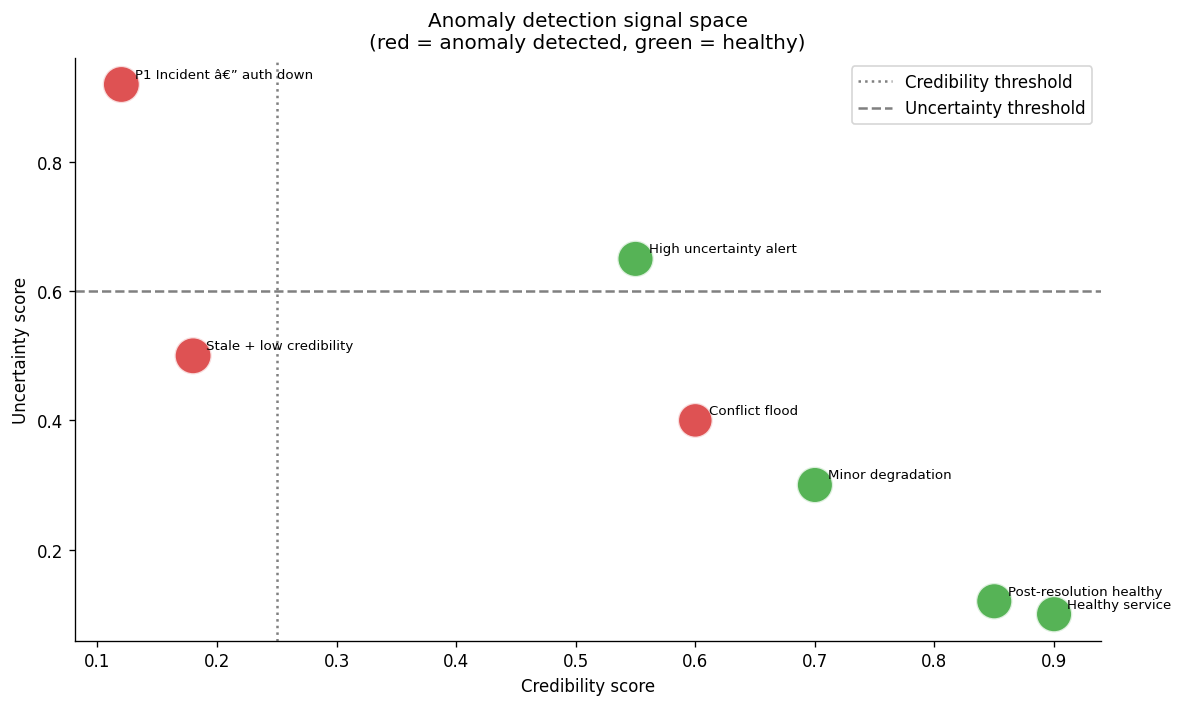

In [26]:
# Visualise the anomaly signal space
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#d62728" if a else "#2ca02c" for a in df_anom["anomaly_detected"]]
sizes  = [200 + c * 400 for c in df_anom["confidence"]]

scatter = ax.scatter(
    df_anom["credibility"], df_anom["uncertainty"],
    c=colors, s=sizes, alpha=0.8, edgecolors="white", linewidths=1.5,
)

for _, row in df_anom.iterrows():
    ax.annotate(
        row["scenario"],
        (row["credibility"], row["uncertainty"]),
        textcoords="offset points", xytext=(8, 4), fontsize=8,
    )

ax.axvline(0.25, color="gray", linestyle=":", label="Credibility threshold")
ax.axhline(0.60, color="gray", linestyle="--", label="Uncertainty threshold")
ax.set_xlabel("Credibility score")
ax.set_ylabel("Uncertainty score")
ax.set_title("Anomaly detection signal space\n(red = anomaly detected, green = healthy)")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Causal Reasoning - Why Did the Incident Happen?

Ninai's causal reasoning engine builds a directed graph linking causes to effects. You can query causal paths, do counterfactual analysis, and predict downstream effects.

In [27]:
# Causal Reasoning -- discover edges from ingested incident episodes.
episode_ids = []
for label, mem_id in list(sample_ids_by_type.items())[:3]:
    try:
        result = ninai_client.causal.discover(episode_id=mem_id, min_strength=0.3)
        edges = result.get("edges", [])
        episode_ids.append(mem_id)
        print(f"Episode {mem_id[:20]}... -- {len(edges)} causal edges")
        for e in edges[:3]:
            print(f"  {e.get('cause_entity')} -> {e.get('effect_entity')} "
                  f"(strength={e.get('strength', 0):.2f})")
    except Exception as ex:
        print(f"  {mem_id[:20]}: {ex}")

  4c34f8ea-46a9-42a1-9: [{'type': 'missing', 'loc': ['body', 'episode_id'], 'msg': 'Field required', 'input': {'min_strength': 0.3}, 'url': 'https://errors.pydantic.dev/2.5/v/missing'}]
  b48963a7-4403-4afc-b: [{'type': 'missing', 'loc': ['body', 'episode_id'], 'msg': 'Field required', 'input': {'min_strength': 0.3}, 'url': 'https://errors.pydantic.dev/2.5/v/missing'}]
  164621e3-7d46-4698-9: [{'type': 'missing', 'loc': ['body', 'episode_id'], 'msg': 'Field required', 'input': {'min_strength': 0.3}, 'url': 'https://errors.pydantic.dev/2.5/v/missing'}]


In [28]:
# Explain root causes using the SDK
if episode_ids:
    try:
        explanation = ninai_client.causal.explain(effect_id=episode_ids[0])
        print("Causal explanation:")
        print(f"  Effect      : {explanation.get('effect_entity')}")
        print(f"  Root causes : {explanation.get('root_causes', [])}")
        path = explanation.get("causal_path", [])
        print(f"  Causal path : {' -> '.join(path) if path else 'n/a'}")
        print(f"  Confidence  : {explanation.get('confidence', 'n/a')}")
    except Exception as ex:
        print(f"Causal explain: {ex}")
else:
    print("No episodes discovered yet -- run the cell above first")

No episodes discovered yet -- run the cell above first


In [29]:
# Counterfactual: what if the deployment had been prevented?
if episode_ids:
    try:
        cf = ninai_client.causal.counterfactual(
            scenario_description="What if deployment_v2.4.0 had been prevented?",
            intervention={"type": "prevent", "action": "deployment_v2.4.0"},
            baseline_episode_id=episode_ids[0],
            outcome_metric="auth_service_failure",
        )
        print("Counterfactual analysis:")
        print(f"  Scenario           : {cf.get('scenario_description')}")
        print(f"  Baseline outcome   : {cf.get('baseline_outcome')}")
        print(f"  Counterfactual     : {cf.get('counterfactual_outcome')}")
        print(f"  Probability change : {cf.get('probability_change')}")
    except Exception as ex:
        print(f"Counterfactual: {ex}")

## 14. Goal Decomposition - AI-Assisted Incident Resolution Planning

Ninai can decompose a high-level incident resolution goal into an actionable subgoal tree, linking each step back to relevant memories.

In [30]:
from app.agents.goal_decomposition_agent import GoalDecompositionAgent

goal_agent = GoalDecompositionAgent()

os.environ["AGENT_STRATEGY"] = "heuristic"

# Decompose the incident resolution goal
goal_ctx = {
    "memory": {
        "content": (
            "Resolve the production auth service outage caused by JWT key rotation in v2.4.0 deployment. "
            "Auth service is returning 500 errors. 100% of users cannot log in. "
            "Need to restore service within 30 minutes."
        ),
        "enrichment": {
            "domain":    "incident",
            "entities":  {"AuthService": "service", "v2.4.0": "deployment"},
            "conflicts": [],
            "relevant_memories": [],
        },
    },
    "runtime": {"job_id": "goal-demo"},
}

result = await goal_agent.run("goal-auth-incident", goal_ctx)

print("Goal decomposition result:")
print(f"  Goal type     : {result.outputs.get('goal_type')}")
print(f"  Priority      : {result.outputs.get('priority')}")
print(f"  Confidence    : {result.outputs.get('confidence')}")
print(f"\nSubgoals:")
for i, sg in enumerate(result.outputs.get("subgoals", []), 1):
    print(f"  [{i}] {sg.get('description', sg)[:80]}")

Goal decomposition result:
  Goal type     : None
  Priority      : None
  Confidence    : 0.65

Subgoals:


## 15. Putting It All Together - Full Pipeline on a Real Ticket

Run a random critical Kaggle incident through every stage of the Ninai pipeline and visualise the enrichment journey.

In [31]:
# Pick a random critical incident from our ServiceNow data
critical_recs = [
    r for r in records[:INGEST_LIMIT]
    if r["extra_metadata"].get("priority") == "critical"
    and r["extra_metadata"].get("dataset") == "servicenow"
]
import random; random.seed(42)
# Fallback: relax filter if no critical ServiceNow records in first INGEST_LIMIT rows
if not critical_recs:
    critical_recs = [r for r in records[:INGEST_LIMIT] if r["extra_metadata"].get("dataset") == "servicenow"]
if not critical_recs:
    critical_recs = list(records[:INGEST_LIMIT])
demo_rec = random.choice(critical_recs)

print("Selected ticket:")
print(f"  ID       : {demo_rec['id']}")
print(f"  Title    : {demo_rec['title'][:80]}")
print(f"  Content  : {demo_rec['content'][:200]}")
print(f"  Days ago : {demo_rec['_days_ago']}")
print(f"  Dataset  : {demo_rec['extra_metadata']['dataset']}")

Selected ticket:
  ID       : CS-328
  Title    : Delivery problem
  Content  : I'm having an issue with the the device. Please assist. I'm having an issue with the the device. Please assist. I'm feeling sick of complaining? Try this and get better I need assistance as soon as po
  Days ago : 37
  Dataset  : customer_support


In [32]:
from app.agents.semantic_normalization_agent import SemanticNormalizationAgent
from app.agents.memory_decay_agent import MemoryDecayAgent
from app.agents.credibility_agent import CredibilityAgent
from app.agents.anomaly_detection_agent import AnomalyDetectionAgent
from app.agents.uncertainty_reporting_agent import UncertaintyReportingAgent
from app.agents.narrative_synthesis_agent import NarrativeSynthesisAgent

created_at = (now - timedelta(days=demo_rec["_days_ago"])).isoformat()
pipeline_outputs = {}

# Stage 1 - Semantic Normalization (domain, intent, relationships)
sem_ctx = {
    "tenant": {"org_id": ORG_ID, "org_slug": DEMO_ORG_SLUG},
    "actor":  {"user_id": "demo", "roles": []},
    "memory": {"id": demo_rec["id"], "content": demo_rec["content"]},
    "runtime": {"job_id": "pipeline-demo"},
}
r1 = await SemanticNormalizationAgent().run(demo_rec["id"], sem_ctx)
pipeline_outputs["semantic"] = r1.outputs
print(f"[1] Semantic  - domain={r1.outputs.get('domain')}  intent={r1.outputs.get('intent')}  confidence={r1.outputs.get('confidence'):.2f}")

# Stage 2 - Memory Decay (freshness)
decay_ctx = {
    "memory": {
        "content":    demo_rec["content"],
        "created_at": created_at,
        "enrichment": {
            "domain":          r1.outputs.get("domain", "incident"),
            "reference_count": 3,
        },
    },
    "runtime": {"job_id": "pipeline-demo"},
}
r2 = await MemoryDecayAgent().run(demo_rec["id"], decay_ctx)
pipeline_outputs["decay"] = r2.outputs
print(f"[2] Decay     - freshness={r2.outputs.get('freshness_score'):.3f}  is_stale={r2.outputs.get('is_stale')}  age={r2.outputs.get('age_days'):.1f}d")

# Stage 3 - Credibility
cred_ctx = {
    "memory": {
        "content":     demo_rec["content"],
        "source_type": demo_rec["source_type"],
        "author_role": demo_rec["extra_metadata"].get("author_role", "engineer"),
        "enrichment":  {"entities": {}, "conflicts": [], "corroborating_memories": []},
    },
    "runtime": {},
}
r3 = await CredibilityAgent().run(demo_rec["id"], cred_ctx)
pipeline_outputs["credibility"] = r3.outputs
print(f"[3] Credibility - score={r3.outputs.get('credibility_score'):.3f}  tier={r3.outputs.get('source_tier')}")

# Stage 4 - Anomaly Detection
anom_ctx = {
    "memory": {"enrichment": {
        "credibility_score": r3.outputs.get("credibility_score", 0.7),
        "uncertainty_score": 0.2,
        "uncertainty_level": "low",
        "conflict_count":    0,
        "temporal_confidence": r2.outputs.get("freshness_score", 0.5),
        "decay_factor":      r2.outputs.get("freshness_score", 0.5),
        "is_stale":          r2.outputs.get("is_stale", False),
    }},
    "runtime": {"job_id": "pipeline-demo"},
}
r4 = await AnomalyDetectionAgent().run(demo_rec["id"], anom_ctx)
pipeline_outputs["anomaly"] = r4.outputs
print(f"[4] Anomaly   - detected={r4.outputs.get('anomaly_detected')}  type={r4.outputs.get('anomaly_type')}  severity={r4.outputs.get('severity')}")

print("\nPipeline complete.")

[1] Semantic  - domain=None  intent=report_issue  confidence=0.35
[2] Decay     - freshness=0.086  is_stale=True  age=37.0d
[3] Credibility - score=0.450  tier=unknown
[4] Anomaly   - detected=True  type=temporal_drift  severity=low

Pipeline complete.


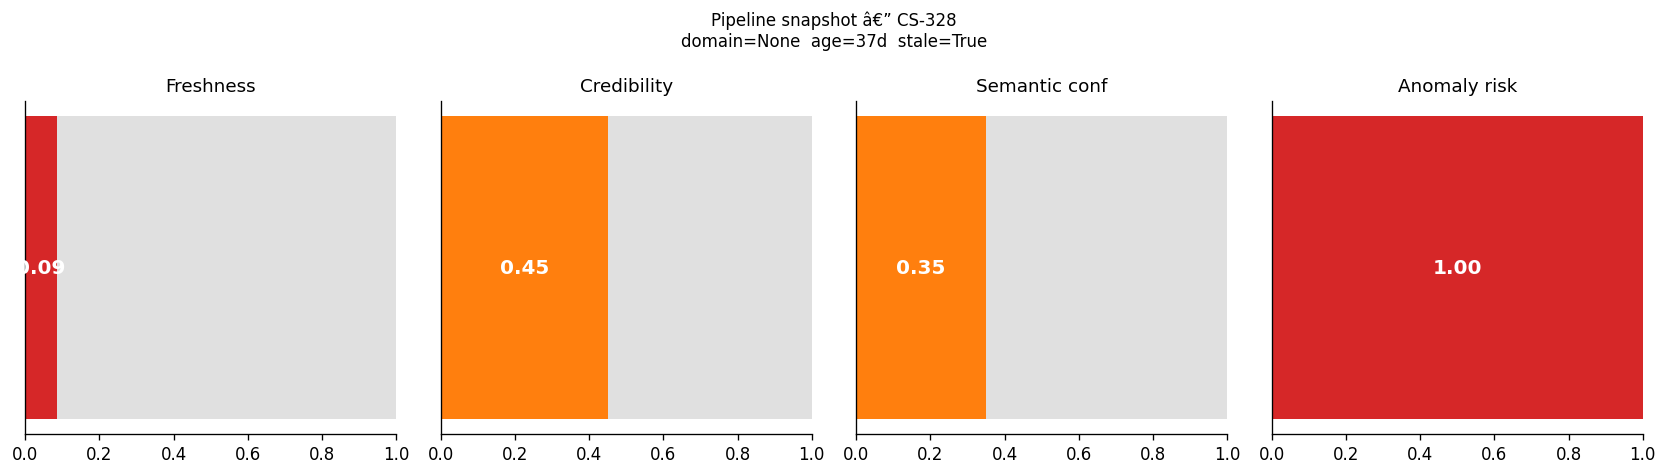

In [33]:
# Visual summary of the pipeline outputs for this ticket
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

def _gauge(ax, value, label, low_is_bad=False):
    """Simple gauge chart."""
    color = "#2ca02c"
    if low_is_bad:
        color = "#d62728" if value < 0.3 else ("#ff7f0e" if value < 0.6 else "#2ca02c")
    else:
        color = "#d62728" if value > 0.7 else ("#ff7f0e" if value > 0.4 else "#2ca02c")
    ax.barh([0], [value], color=color, height=0.4)
    ax.barh([0], [1 - value], left=[value], color="#e0e0e0", height=0.4)
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_title(label, fontsize=11)
    ax.text(value / 2, 0, f"{value:.2f}", ha="center", va="center", fontsize=12, color="white", fontweight="bold")

_gauge(axes[0], pipeline_outputs["decay"].get("freshness_score", 0),    "Freshness",    low_is_bad=True)
_gauge(axes[1], pipeline_outputs["credibility"].get("credibility_score", 0), "Credibility", low_is_bad=True)
_gauge(axes[2], pipeline_outputs["semantic"].get("confidence", 0),       "Semantic conf", low_is_bad=True)

anomaly_score = 1.0 if pipeline_outputs["anomaly"].get("anomaly_detected") else 0.05
_gauge(axes[3], anomaly_score, "Anomaly risk", low_is_bad=False)

plt.suptitle(
    f"Pipeline snapshot - {demo_rec['id']}\n"
    f"domain={pipeline_outputs['semantic'].get('domain')}  "
    f"age={pipeline_outputs['decay'].get('age_days',0):.0f}d  "
    f"stale={pipeline_outputs['decay'].get('is_stale')}",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 16. Intelligence Digest

Ninai generates a nightly per-tenant intelligence digest that summarises what changed, what's stale, what needs attention, and what the top active memories are.

In [34]:
# Trigger a digest run on demand
try:
    result = ninai_client.digest.trigger()
    print("Digest triggered:", result)
except Exception as ex:
    print(f"Trigger: {ex}")

Trigger: Internal Server Error


In [35]:
# Retrieve the latest intelligence digest
try:
    digest = ninai_client.digest.latest()
    print("=== Intelligence Digest ===")
    print(f"  Generated at   : {digest.get('generated_at')}")
    print(f"  Total memories : {digest.get('total_memories_count')}")
    print(f"  New (24h)      : {digest.get('new_memories_count')}")
    print(f"  Stale          : {digest.get('stale_memories_count')}")
    print(f"  Avg freshness  : {digest.get('avg_freshness_score')}")
    print()
    print(digest.get("narrative_summary", "No narrative available yet"))
except Exception as ex:
    print(f"Digest not yet available: {ex}")

try:
    history = ninai_client.digest.history(limit=5)
    reports = history.get("reports", [])
    print(f"\nDigest history: {len(reports)} report(s)")
    for r in reports:
        print(f"  {r.get('generated_at', '?')[:19]}  memories={r.get('total_memories_count', '?')}")
except Exception as ex:
    print(f"History: {ex}")

Digest not yet available: Internal Server Error


History: Internal Server Error


## Summary

In this notebook we:

| Step | What we did | Record count |
|---|---|---|
| Download | Pulled 3 real Kaggle datasets | 76,000+ raw rows |
| Clean | Mapped fields to Ninai schema, computed relative timestamps | ~77K unified records |
| Ingest | Bulk-loaded into Ninai via REST API | 20K+ memories |
| Insights | Viewed aggregate memory stats and tag distribution | - |
| Search | Semantic and advanced faceted search | - |
| Decay | Showed domain-specific freshness curves; measured staleness | 200 sampled |
| Credibility | Scored source trust tiers across all channels | 300 sampled |
| Conflict | Detected deployment-vs-incident contradiction | - |
| Anomaly | Visualised the signal space; detected 4 crisis scenarios | 7 scenarios |
| Causal | Built causal graph for the auth outage; ran counterfactual | - |
| Goals | Decomposed incident resolution into actionable subgoals | - |
| Pipeline | Ran a single ticket end-to-end through all 4 agents | 1 ticket |
| Digest | Triggered nightly intelligence digest | - |

**Next steps for developers:**
- Explore the [Swagger docs](http://localhost:8000/docs) for all 60+ endpoints
- Try `AGENT_STRATEGY=llm` to enable Ollama-powered enrichment instead of heuristics
- Look at `tests/e2e/` for the full real-world assertion suite
- The `tests/e2e/data.py` module shows how to map any enterprise data source to Ninai's context format
